# Repelling and attracting LCS as strain tensor lines

The FTLE map (see `cabo_verde_ftle`) shows *where* the flow stretches, but not
the material curves themselves. Haller (2015, §5.1) constructs those curves
directly from the Cauchy–Green strain tensor $C = (\nabla F)^\top \nabla F$,
whose eigenpairs satisfy $C\,\xi_i = \lambda_i\,\xi_i$ with
$0 < \lambda_1 \le \lambda_2$ and $\xi_1 \perp \xi_2$:

- a **repelling** LCS is a curve tangent to $\xi_1$ — the weak-stretch
  eigenvector (a "shrink line", $\dot r = \xi_1(r)$);
- an **attracting** LCS is a curve tangent to $\xi_2$ — the strong-stretch
  eigenvector (a "stretch line", $\dot r = \xi_2(r)$).

So each LCS is just a trajectory of the *other* eigenvector field. This
notebook advects a grid over Cabo Verde, builds $C$ with `lcs_parcels`, and
integrates those two ODEs to draw the LCS skeleton over the FTLE.

It reads the bundled current subset, so it runs offline — no CMEMS
credentials. Run with `pixi run -e examples jupytext --sync --execute
examples/cabo_verde_lcs.py`.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from parcels import FieldSet, ParticleSet, Particle, StatusCode
from parcels.kernels import AdvectionRK4
from parcels.convert import copernicusmarine_to_sgrid

from lcs_parcels import NeighborSeed

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_5802/1290272160.py:5: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, ParticleSet, Particle, StatusCode


## Currents

The same CMEMS hourly surface velocity as `cabo_verde_ftle`, saved to a file
so the notebook is self-contained. `copernicusmarine_to_sgrid` +
`from_sgrid_conventions` wrap it as a spherical `FieldSet`.

In [2]:
currents = xr.open_dataset("data/cabo_verde_currents_hourly.nc")
sgrid = copernicusmarine_to_sgrid(fields={"U": currents["uo"], "V": currents["vo"]})
fieldset = FieldSet.from_sgrid_conventions(sgrid, mesh="spherical")
z_surface = float(currents["depth"].values[0])

## Seed and advect

A rectilinear `NeighborSeed` over the release box emits one particle per grid
point; we run RK4 forward for $T$ and ingest the finals into a `FlowMap`. The
recovery kernel turns lost particles into `NaN` in place so losses propagate.

In [3]:
t0 = np.datetime64("2025-08-01")
T = np.timedelta64(10, "D")            # signed window; sign(T) sets the direction
t1 = t0 + T

resolution_deg = 1 / 25
seed_lon, seed_lat = (-27.0, -21.0), (13.5, 18.5)

In [4]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)

In [5]:
lon_axis = np.arange(seed_lon[0], seed_lon[1] + 1e-9, resolution_deg)
lat_axis = np.arange(seed_lat[0], seed_lat[1] + 1e-9, resolution_deg)
seed = NeighborSeed.from_axes(lon_axis, lat_axis)

lon, lat = seed.to_parcels_pset()
lon, lat = np.asarray(lon, dtype=float), np.asarray(lat, dtype=float)
pset = ParticleSet(
    fieldset, pclass=Particle,
    x=lon, y=lat, z=np.full(lon.size, z_surface), t=np.full(lon.size, t0),
)
pset.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"), runtime=T, verbose_progress=False,
)
flowmap = seed.pset_to_flowmap(
    np.asarray(pset.x, dtype=float), np.asarray(pset.y, dtype=float), t0=t0, t1=t1
)

## Strain eigenvectors

`cg_eigen` returns the eigenvalues $\lambda_i$ and orthonormal eigenvectors
$\xi_i$ of $C$ on the grid (components in the local east/north metres frame).
`ftle` uses $\lambda_2$; we keep it as the background field and to pick where
to start the lines.

In [6]:
# drop the scalar `eig` coord left by ftle()'s lambda_max pick, so the auto plot
# title stays about the FTLE, not the eigen index.
ftle = (flowmap.ftle() * 86400.0).rename("FTLE").drop_vars("eig")   # 1/day
cauchy_green = flowmap.cauchy_green()

## Tracing a tensor line

A tensor line is a trajectory of $\dot r = \xi_k(r)$. Two wrinkles make it more
than a plain ODE solve:

- **No global orientation.** $\xi_k$ and $-\xi_k$ are both eigenvectors, so at
  each step we flip the sign to keep heading the same way.
- **Interpolating a tensor, not a vector.** We bilinearly interpolate the four
  smooth components of $C$ at the current point, then re-diagonalise there —
  this avoids the sign ambiguity of interpolating $\xi$ directly.

We march every seed at once (a midpoint step in arc length) and let points that
leave the domain or hit land go `NaN`, which ends that line. Below the tensor
grid is plain NumPy — the tight inner loop is the one place we drop out of
xarray.

In [7]:
# Cauchy–Green tensor as a plain (nlon, nlat, 2, 2) array on the release grid.
C_grid = cauchy_green.transpose("i", "j", "row", "col").values
dlon = lon_axis[1] - lon_axis[0]
dlat = lat_axis[1] - lat_axis[0]
R = 6_371_000.0  # earth radius (m), matching lcs_parcels' metres frame


def interp_C(lon, lat):
    """Bilinear-interpolate C at points (lon, lat); NaN outside the grid."""
    gx = (lon - lon_axis[0]) / dlon
    gy = (lat - lat_axis[0]) / dlat
    inside = (gx >= 0) & (gx <= len(lon_axis) - 1) & (gy >= 0) & (gy <= len(lat_axis) - 1)
    # `inside` is already False at NaN points; zero them so the int cast is quiet.
    i0 = np.clip(np.floor(np.where(inside, gx, 0)), 0, len(lon_axis) - 2).astype(int)
    j0 = np.clip(np.floor(np.where(inside, gy, 0)), 0, len(lat_axis) - 2).astype(int)
    fx = (gx - i0)[:, None, None]
    fy = (gy - j0)[:, None, None]
    C = (
        C_grid[i0, j0] * (1 - fx) * (1 - fy)
        + C_grid[i0 + 1, j0] * fx * (1 - fy)
        + C_grid[i0, j0 + 1] * (1 - fx) * fy
        + C_grid[i0 + 1, j0 + 1] * fx * fy
    )
    C[~inside] = np.nan
    return C


def eigenvector(pos, k, heading):
    """Unit eigenvector k of C at pos, oriented to follow `heading` (or NaN)."""
    C = interp_C(pos[:, 0], pos[:, 1])
    bad = ~np.isfinite(C).all(axis=(1, 2))
    _, vecs = np.linalg.eigh(np.where(bad[:, None, None], np.eye(2), C))
    v = vecs[:, :, k]
    flip = np.sum(v * heading, axis=1) < 0
    v[flip] = -v[flip]
    v[bad] = np.nan
    return v


def step_degrees(pos, v, ds_m):
    """Advance `pos` (lon, lat) by arc length `ds_m` along metres-frame vector v."""
    m_per_deg_lat = R * np.pi / 180
    m_per_deg_lon = m_per_deg_lat * np.cos(np.radians(pos[:, 1]))
    step = np.column_stack([v[:, 0] / m_per_deg_lon, v[:, 1] / m_per_deg_lat]) * ds_m
    return pos + step


def half_line(seeds, k, sign, ds_m=3_000.0, n_steps=120):
    """March all seeds one way (`sign` = ±1) along eigenvector field k."""
    pos = seeds.astype(float)
    heading = sign * eigenvector(pos, k, np.ones_like(pos))  # pick the initial branch
    track = [pos.copy()]
    for _ in range(n_steps):
        v1 = eigenvector(pos, k, heading)
        v2 = eigenvector(step_degrees(pos, v1, 0.5 * ds_m), k, v1)
        pos = step_degrees(pos, v2, ds_m)
        heading = v2
        track.append(pos.copy())
    return np.stack(track)  # (n_steps+1, n_seeds, 2)


def tensor_lines(seeds, k):
    """Full tensor lines through `seeds` (both directions) as a list of polylines."""
    back = half_line(seeds, k, -1)[::-1]
    fwd = half_line(seeds, k, +1)
    both = np.concatenate([back, fwd[1:]])          # (steps, n_seeds, 2)
    return [both[:, s] for s in range(seeds.shape[0])]

## Where to start the lines

Repelling LCS live on ridges of the forward FTLE, so we start both families
from the strong-deformation points — the local FTLE maxima above the 90th
percentile, keeping the strongest few dozen for a legible plot. Through each,
$\xi_1$ traces the repelling LCS and $\xi_2$ the transverse attracting LCS.

In [8]:
roll_max = ftle.rolling(i=3, j=3, center=True, min_periods=1).max()
is_ridge = (ftle >= roll_max) & (ftle >= ftle.quantile(0.90))

mask = is_ridge.transpose("i", "j").values
lon0 = flowmap.ds["lon_0"].transpose("i", "j").values
lat0 = flowmap.ds["lat_0"].transpose("i", "j").values
strongest = np.argsort(ftle.transpose("i", "j").values[mask])[::-1][:50]
seeds = np.column_stack([lon0[mask], lat0[mask]])[strongest]

repelling = tensor_lines(seeds, k=0)   # shrink lines, tangent to xi_1
attracting = tensor_lines(seeds, k=1)  # stretch lines, tangent to xi_2
print(f"{len(seeds)} seed points")

50 seed points


## LCS over the FTLE

(13.5, 18.5)

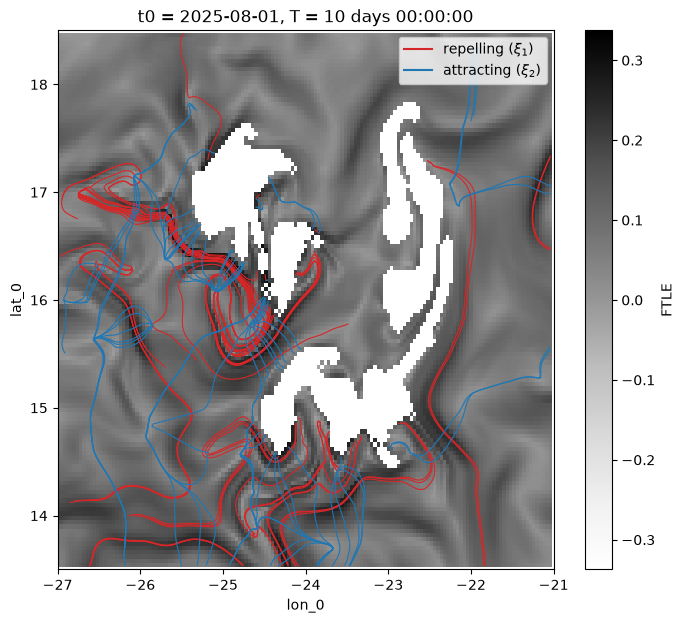

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))
ftle.plot.pcolormesh(x="lon_0", y="lat_0", ax=ax, cmap="Greys", add_colorbar=True)
for line in repelling:
    ax.plot(line[:, 0], line[:, 1], color="tab:red", lw=0.8)
for line in attracting:
    ax.plot(line[:, 0], line[:, 1], color="tab:blue", lw=0.8)
ax.plot([], [], color="tab:red", label="repelling ($\\xi_1$)")
ax.plot([], [], color="tab:blue", label="attracting ($\\xi_2$)")
ax.legend(loc="upper right")
ax.set_xlim(seed_lon)
ax.set_ylim(seed_lat)